In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load data
daily_sales = pd.read_csv('../data/processed/daily_sales_CA1_FOODS.csv')
daily_sales['date'] = pd.to_datetime(daily_sales['date'])
daily_sales = daily_sales.sort_values('date').reset_index(drop=True)

# Split train/test
FORECAST_HORIZON = 28
train = daily_sales[:-FORECAST_HORIZON].copy()
test = daily_sales[-FORECAST_HORIZON:].copy()

print("✅ Data loaded and split")
print(f"Training: {train['date'].min().date()} to {train['date'].max().date()} ({len(train):,} days)")
print(f"Test: {test['date'].min().date()} to {test['date'].max().date()} ({len(test)} days)")

✅ Data loaded and split
Training: 2011-01-29 to 2016-04-24 (1,913 days)
Test: 2016-04-25 to 2016-05-22 (28 days)


In [12]:
def mape(actual, predicted):

    actual = np.array(actual)
    predicted = np.array(predicted)
    # Avoid division by zero
    mask = actual > 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

def mae(actual, predicted):
    """Mean Absolute Error - in units"""
    return np.mean(np.abs(np.array(actual) - np.array(predicted)))

print("✅ Metrics defined")
print("We'll use MAPE (%) and MAE (units) to compare models")

✅ Metrics defined
We'll use MAPE (%) and MAE (units) to compare models


In [13]:
# Forecast:
# predict tomorrow = today's value

naive_forecast = np.full(
    FORECAST_HORIZON,
    train['total_sales'].iloc[-1]
)

naive_mape = mape(test['total_sales'], naive_forecast)
naive_mae = mae(test['total_sales'], naive_forecast)

print("=== NAIVE FORECAST (Last Value) ===")
print(f"MAPE: {naive_mape:.1f}%")
print(f"MAE:  {naive_mae:.0f} units/day")
print(f"\nThis means our naive forecast is off by {naive_mape:.1f}% on average")

=== NAIVE FORECAST (Last Value) ===
MAPE: 31.0%
MAE:  894 units/day

This means our naive forecast is off by 31.0% on average


In [14]:
# 7-day moving average
# Average of last 7 days as forecast

window = 7
last_window = train['total_sales'].iloc[-window:].values
ma_forecast_value = np.mean(last_window)
ma_forecast = np.full(FORECAST_HORIZON, ma_forecast_value)

ma_mape = mape(test['total_sales'], ma_forecast)
ma_mae = mae(test['total_sales'], ma_forecast)

print("=== 7-DAY MOVING AVERAGE ===")
print(f"MAPE: {ma_mape:.1f}%")
print(f"MAE:  {ma_mae:.0f} units/day")

=== 7-DAY MOVING AVERAGE ===
MAPE: 13.8%
MAE:  487 units/day


In [15]:
# Seasonal naive:
# predict same day last week
# This captures the weekend pattern

seasonal_forecast = []
for i in range(FORECAST_HORIZON):
    # Go back 7 days from the forecast position
    idx = len(train) - FORECAST_HORIZON + i - 7
    if idx >= 0:
        seasonal_forecast.append(train['total_sales'].iloc[idx])
    else:
        seasonal_forecast.append(train['total_sales'].mean())

seasonal_forecast = np.array(seasonal_forecast)

seasonal_mape = mape(test['total_sales'], seasonal_forecast)
seasonal_mae = mae(test['total_sales'], seasonal_forecast)

print("=== SEASONAL NAIVE (Same Day Last Week) ===")
print(f"MAPE: {seasonal_mape:.1f}%")
print(f"MAE:  {seasonal_mae:.0f} units/day")

=== SEASONAL NAIVE (Same Day Last Week) ===
MAPE: 9.9%
MAE:  325 units/day


In [16]:
results = pd.DataFrame({
    'Model': ['Naive (Last Value)',
              '7-Day Moving Average',
              'Seasonal Naive (Same Day Last Week)'],
    'MAPE (%)': [naive_mape, ma_mape, seasonal_mape],
    'MAE (units)': [naive_mae, ma_mae, seasonal_mae]
})

results = results.sort_values('MAPE (%)').reset_index(drop=True)

print("=== MODEL COMPARISON ===")
print(results.to_string(index=False))
print(f"\n🏆 Best so far: {results.iloc[0]['Model']}")
print(f"   MAPE: {results.iloc[0]['MAPE (%)']:.1f}%")

=== MODEL COMPARISON ===
                              Model  MAPE (%)  MAE (units)
Seasonal Naive (Same Day Last Week)  9.909921   325.035714
               7-Day Moving Average 13.771304   486.964286
                 Naive (Last Value) 30.952979   894.107143

🏆 Best so far: Seasonal Naive (Same Day Last Week)
   MAPE: 9.9%


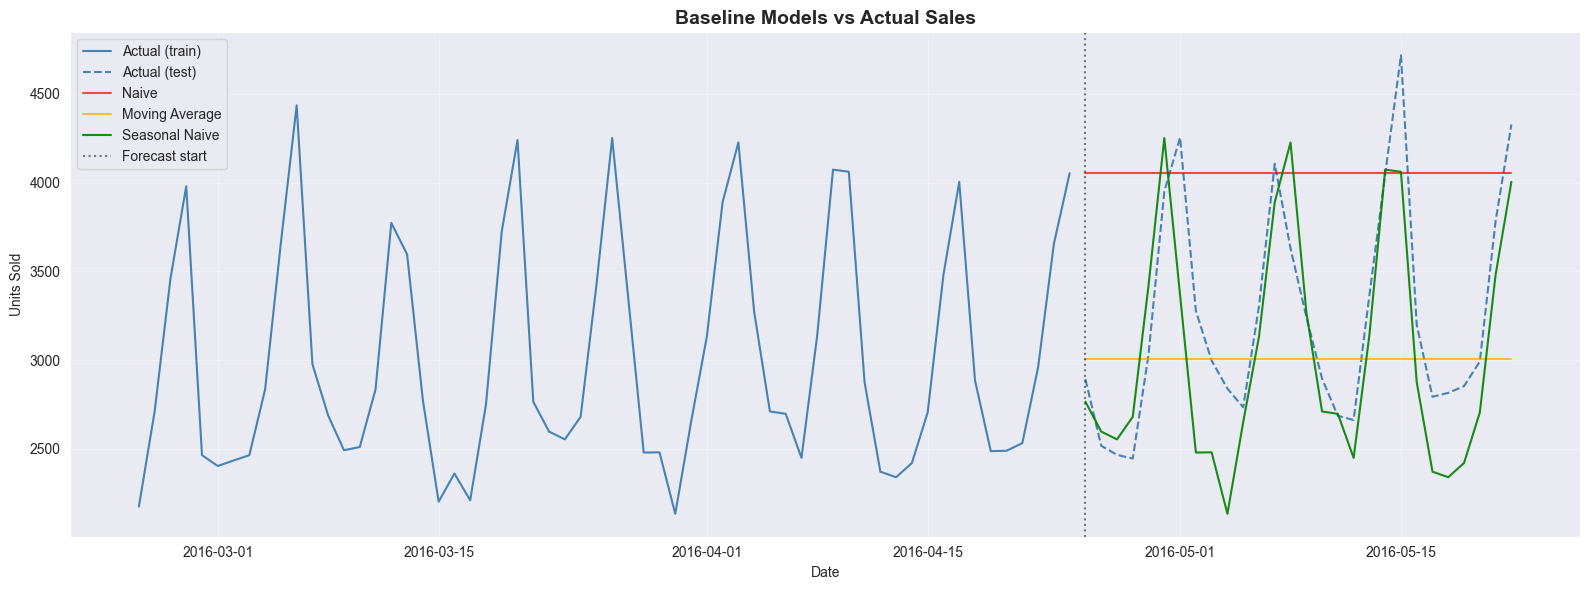

In [17]:
plt.figure(figsize=(16, 6))

# Show last 60 days of training + test period
plot_train = train.tail(60)

plt.plot(plot_train['date'], plot_train['total_sales'],
         color='steelblue', label='Actual (train)', linewidth=1.5)
plt.plot(test['date'], test['total_sales'],
         color='steelblue', linestyle='--',
         label='Actual (test)', linewidth=1.5)
plt.plot(test['date'], naive_forecast,
         color='red', label='Naive', linewidth=1.5, alpha=0.7)
plt.plot(test['date'], ma_forecast,
         color='orange', label='Moving Average',
         linewidth=1.5, alpha=0.7)
plt.plot(test['date'], seasonal_forecast,
         color='green', label='Seasonal Naive',
         linewidth=1.5, alpha=0.9)

plt.axvline(x=test['date'].iloc[0],
            color='black', linestyle=':', alpha=0.5,
            label='Forecast start')
plt.title('Baseline Models vs Actual Sales',
          fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
best_model = results.iloc[0]
best_mape = best_model['MAPE (%)']
best_mae = best_model['MAE (units)']
avg_daily_sales = test['total_sales'].mean()

print("=== BUSINESS INTERPRETATION ===")
print(f"\nBest baseline model: {best_model['Model']}")
print(f"Forecast error: {best_mape:.1f}% MAPE")
print(f"In units: off by ~{best_mae:.0f} units per day on average")
print(f"Average daily sales: {avg_daily_sales:.0f} units")
print(f"\nThis means on a typical day selling {avg_daily_sales:.0f} units,")
print(f"the best baseline is wrong by ~{best_mae:.0f} units")
print(f"\nNext step: Can XGBoost beat {best_mape:.1f}% MAPE?")
print(f"That's the question will be answered in notebook 03.")

=== BUSINESS INTERPRETATION ===

Best baseline model: Seasonal Naive (Same Day Last Week)
Forecast error: 9.9% MAPE
In units: off by ~325 units per day on average
Average daily sales: 3244 units

This means on a typical day selling 3244 units,
the best baseline is wrong by ~325 units

Next step: Can XGBoost beat 9.9% MAPE?
That's the question will be answered in notebook 03.
